# 02 — KPI Definition

This notebook defines and calculates the core revenue and customer KPIs: Gross/Net Sales, Return Rate, and AOV at the revenue level; Repeat Purchase Rate and Cohort Month at the customer level. **Input:** `revenue_df.csv` (full transaction set) and `customer_df.csv` (customer-attributed subset) from `01_data_cleaning`. It answers: what is net revenue after returns, and what share of customers are repeat buyers?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')
revenue_df = pd.read_csv('../data/processed/revenue_df.csv')

## KPI Definitions & Scope

**Exclusions (applied in `01_data_cleaning`):**
- Invoices prefixed 'A' — bad debt adjustments, not customer transactions
- Non-cancelled negative-quantity rows with Price = 0 and no Customer ID —
  internal stock adjustments/write-offs (damage, loss), not customer returns

**Revenue-level analysis** (uses full transaction set, Customer ID not required):
- Gross Sales = sum(Quantity × Price) for non-cancelled invoices (no 'C' prefix)
- Returns = sum(Quantity × Price) for 'C'-prefixed invoices (cancellations; naturally negative)
- Net Sales = Gross Sales + Returns

**Customer-level analysis** (Gross Sales df filtered to non-null Customer ID):
- Purchase = an invoice with positive net quantity/revenue (i.e., not a 'C' invoice)
- Repeat Customer = a customer with more than 1 distinct non-cancelled invoice
- Cohort = calendar month of customer's first purchase invoice
- Unit of analysis = invoice-level nets aggregated per Customer ID

**Note on scope:** revenue KPIs (Gross/Net Sales) include guest/null-Customer-ID
transactions since they represent real revenue; customer-level KPIs (repeat
purchase, cohort, RFM) necessarily exclude them since they can't be attributed
to a customer.

# Revenue-Level Analysis

## Gross Sales

### Parse Dates
Convert `InvoiceDate` to datetime and derive a monthly period, used for every time-based aggregation below.

In [3]:
revenue_df['InvoiceDate'] = pd.to_datetime(revenue_df['InvoiceDate'])
revenue_df['InvoiceMonth'] = revenue_df['InvoiceDate'].dt.to_period('M')

### Gross Sales Total
Sum of line revenue for non-cancelled invoices.

In [4]:
revenue_gross_sales = revenue_df[~revenue_df['is_cancelled']]['line_revenue'].sum() 
revenue_gross_sales
# is cancelled is false so it means total invoices which are not cancelled and we are summing the gross revenue of those invoices to get the total gross sales

10631066.744000003

## Returns

In [5]:
returns = revenue_df[revenue_df['is_cancelled']]['line_revenue'].sum()
returns
#cancled invoices are the ones which are returned so we are summing the gross revenue of those invoices to get the total returns

-893979.7300000001

## Net Sales

In [6]:
net_sale = revenue_gross_sales + returns
net_sale

9737087.014000002

### Gross / Returns / Net Sales by Month
Monthly trend comparison. Net is computed directly from the full, unfiltered data since `line_revenue` is already signed (negative for cancellations), so it nets out automatically.

<Axes: title={'center': 'Gross / Returns / Net Sales by Month'}, xlabel='InvoiceMonth'>

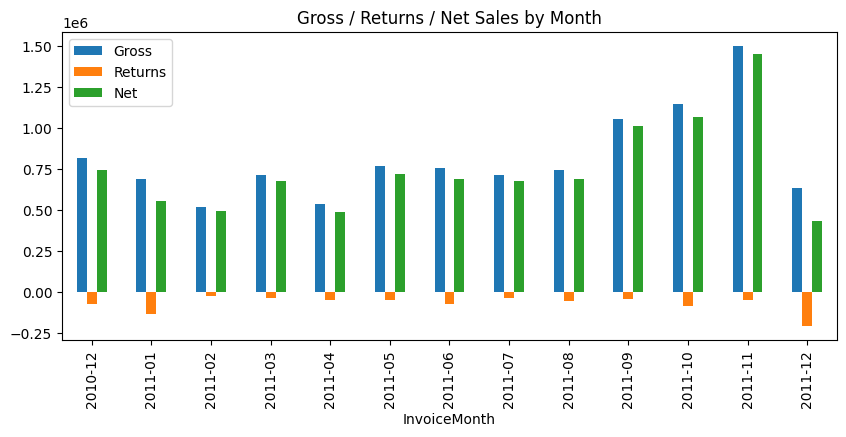

In [7]:
gross_by_month = revenue_df[~revenue_df['is_cancelled']].groupby('InvoiceMonth')['line_revenue'].sum()
returns_by_month = revenue_df[revenue_df['is_cancelled']].groupby('InvoiceMonth')['line_revenue'].sum()
net_by_month = revenue_df.groupby('InvoiceMonth')['line_revenue'].sum()

sales_by_month = pd.DataFrame({
    'Gross': gross_by_month,
    'Returns': returns_by_month,
    'Net': net_by_month,
})

sales_by_month.plot(kind='bar', figsize=(10, 4), title='Gross / Returns / Net Sales by Month')

### Return Rate
Returns as a percentage of Gross Sales.

In [8]:
return_rate = (abs(returns / revenue_gross_sales))*100
return_rate

8.40912536368514

### AOV (Average Order Value)
Gross Sales ÷ number of distinct non-cancelled invoices.

In [9]:
aov = revenue_gross_sales / revenue_df[~revenue_df['is_cancelled']]['Invoice'].nunique()
aov

512.9585883715321

## Revenue-Level Summary

In [10]:
print(f"Gross Sales:  £{revenue_gross_sales:,.2f}")
print(f"Returns:      £{returns:,.2f}")
print(f"Net Sales:    £{net_sale:,.2f}")
print(f"Return Rate:  {return_rate:.2f}%")
print(f"AOV:          £{aov:,.2f}")

Gross Sales:  £10,631,066.74
Returns:      £-893,979.73
Net Sales:    £9,737,087.01
Return Rate:  8.41%
AOV:          £512.96


# Customer-Level Analysis

### Customer-Attributed Gross Sales
Gross Sales total restricted to invoices with a known Customer ID.

In [11]:
customer_gross_sales = customer_df[~customer_df['is_cancelled']]['line_revenue'].sum() 
customer_gross_sales

8887226.894000003

### Preview
Sanity-check the resulting `customer_df`.

In [12]:
customer_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,line_revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
...,...,...,...,...,...,...,...,...,...,...
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,False,12.60
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,False,16.60
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,False,16.60
401603,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,False,14.85


### Orders per Customer
Distinct non-cancelled invoices per customer.

In [13]:
orders_per_customer = customer_df[~customer_df['is_cancelled']].groupby('Customer ID')['Invoice'].nunique()
orders_per_customer.describe()

count    4339.000000
mean        4.271952
std         7.705493
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       210.000000
Name: Invoice, dtype: float64

### Repeat Customer Flag
A customer with more than 1 non-cancelled order.

In [14]:
is_repeat_customer = orders_per_customer > 1
is_repeat_customer.sum()

2845

### Repeat Purchase Rate
% of customers who are repeat customers.

In [15]:
repeat_purchase_rate = is_repeat_customer.mean() * 100
repeat_purchase_rate

65.56810324959667

### Cohort Month
Calendar month of each customer's first non-cancelled purchase.

In [16]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])
cohort_month = customer_df[~customer_df['is_cancelled']].groupby('Customer ID')['InvoiceDate'].min().dt.to_period('M')
cohort_month.head()

Customer ID
12346    2011-01
12347    2010-12
12348    2010-12
12349    2011-11
12350    2011-02
Name: InvoiceDate, dtype: period[M]

## Customer-Level Summary

In [17]:
print(f"Customers:            {orders_per_customer.shape[0]:,}")
print(f"Repeat Customers:     {is_repeat_customer.sum():,}")
print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")
print(f"Customer Gross Sales: £{customer_gross_sales:,.2f}")

Customers:            4,339
Repeat Customers:     2,845
Repeat Purchase Rate: 65.57%
Customer Gross Sales: £8,887,226.89


## Takeaways

Net Sales came to £9,737,087 after an 8.41% return rate ate into £10,631,067 of Gross Sales — a meaningful but not alarming share of transactions get cancelled. Average Order Value sits at £512.96.

At the customer level, 65.57% of identified customers are repeat buyers (2,845 of 4,339) — a healthy repeat-purchase rate on its face, though `04`'s cohort analysis shows this masks a steep month-over-month drop-off rather than steady reordering.

Guest/unattributed transactions matter: customer-attributed Gross Sales (£8,887,227) is only ~84% of total Gross Sales — roughly a sixth of revenue comes from orders with no Customer ID, real money that customer-level KPIs (repeat rate, cohort, RFM) structurally can't see.